# Notebook 2: Dimensionality Reduction - PCA and LDA

**Project Title**: Intelligent Customer Behavior Analysis and Dynamic Marketing Strategy  
**Objective**: This notebook implements Principal Component Analysis (PCA) and Linear Discriminant Analysis (LDA) to reduce dimensions, capture purchase preferences, and benchmark classifier projections.

### Why PCA and LDA:
- **PCA (Unsupervised)**: Standardizes and projects category spend percentages to orthogonal directions of maximal variance. This avoids multicollinearity and isolates key shopping styles.
- **LDA (Supervised)**: Finds linear boundaries that maximize separation between High Value and Low Value customer labels.

### What We Will Accomplish:
1. Standardize *only* the category spend percentage features (using standard scaler fit on train data).
2. Apply PCA to find components capturing at least 90% of the total variance.
3. Visualize the PC1 vs PC2 space, colored by customer value label.
4. Apply LDA using the High Value target label.
5. Benchmark performance of a baseline classifier (Logistic Regression) on Raw, PCA, and LDA features in a comparison table.

### Step 1: Import Libraries and Load Data
We import pandas, numpy, sklearn modules, and local packages from `src/`.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))
from src.dimensionality import standardize_features, run_pca, run_lda, compare_features_baseline

%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


### Step 2: Extract Category Spend Columns and Standardize
We load the customer profiles and standardize the category spend percentages. Scaling parameters are fit *only* on the training set.

In [2]:
df = pd.read_csv('../data/processed_customers.csv')
print(f"Loaded {df.shape[0]} customer records.")

# Identify category spend columns
cat_cols = [col for col in df.columns if col.endswith('_Spend_Pct')]
print("Category columns to project:", cat_cols)

# Filter splits
train_df = df[df['Split'] == 'Train']
val_df = df[df['Split'] == 'Val']
test_df = df[df['Split'] == 'Test']

# Standardize ONLY category spend % columns
train_scaled, val_scaled, test_scaled, scaler = standardize_features(
    train_df, val_df, test_df, cat_cols
)
print("Standardization complete.")

Loaded 5860 customer records.
Category columns to project: ['Homeware_Spend_Pct', 'Stationery_Spend_Pct', 'Gadgets_Spend_Pct', 'Decorations_Spend_Pct', 'Kitchenware_Spend_Pct', 'Else_Spend_Pct']
Standardization complete.


### Step 3: Run Unsupervised PCA
We fit PCA on the training set and project all subsets. We compute variance curves and automatically select the minimum number of components explaining at least 90% variance.

In [3]:
pca, train_pca, val_pca, test_pca, n_comp = run_pca(
    train_scaled, val_scaled, test_scaled, cat_cols, target_variance=0.90
)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)
print(f"Optimal Components covering 90%+ variance: {n_comp}")
for i, ev in enumerate(explained_var):
    print(f"  - PC{i+1}: Explained Var = {ev*100:.2f}%, Cumulative = {cum_var[i]*100:.2f}%")

Optimal Components covering 90%+ variance: 5
  - PC1: Explained Var = 27.99%, Cumulative = 27.99%
  - PC2: Explained Var = 20.00%, Cumulative = 47.99%
  - PC3: Explained Var = 19.30%, Cumulative = 67.29%
  - PC4: Explained Var = 16.71%, Cumulative = 84.00%
  - PC5: Explained Var = 16.00%, Cumulative = 100.00%


### Step 4: Plot PCA Variance Curves and PC1 vs PC2 Scatter Plot
We draw an explained variance scree plot and a scatter plot of projected coordinates colored by the High Value label.

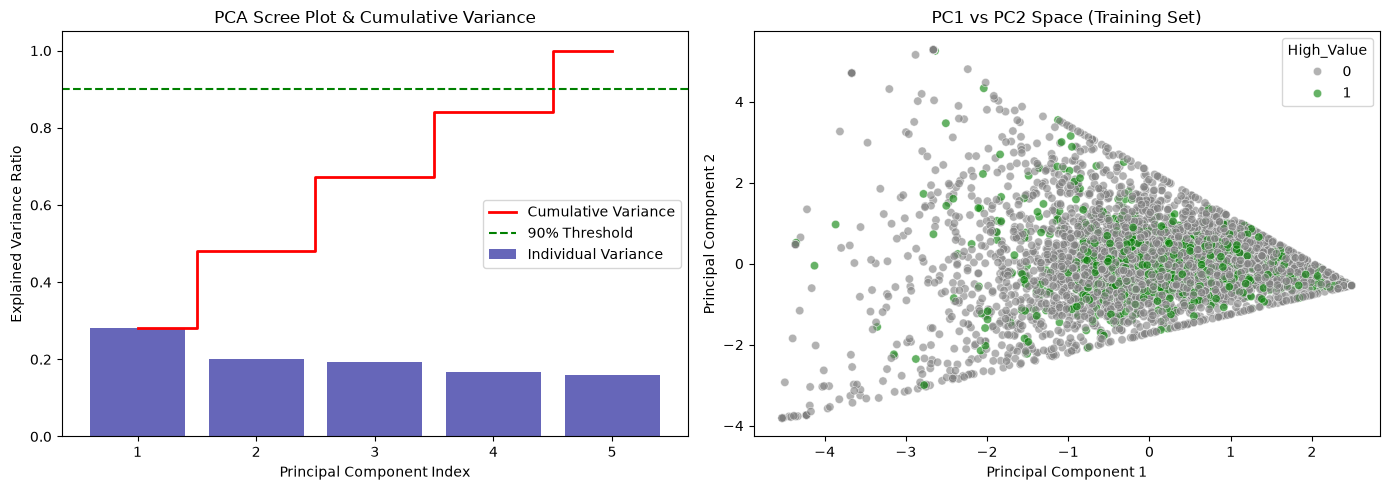

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Variance curves
axes[0].bar(range(1, len(explained_var)+1), explained_var, alpha=0.6, align='center', label='Individual Variance', color='darkblue')
axes[0].step(range(1, len(cum_var)+1), cum_var, where='mid', label='Cumulative Variance', color='red', lw=2)
axes[0].axhline(y=0.90, color='g', linestyle='--', label='90% Threshold')
axes[0].set_xlabel('Principal Component Index')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot & Cumulative Variance')
axes[0].legend(loc='best')

# Subplot 2: PC1 vs PC2 Scatter plot
train_pca_labels = train_pca.copy()
train_pca_labels['High_Value'] = train_scaled['High_Value'].values
sns.scatterplot(
    data=train_pca_labels, x='PC1', y='PC2', hue='High_Value', 
    palette={0: 'gray', 1: 'green'}, alpha=0.6, ax=axes[1]
)
axes[1].set_title('PC1 vs PC2 Space (Training Set)')
axes[1].set_xlabel('Principal Component 1')
axes[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.savefig('../data/plots/pca_analysis.png', dpi=300)
plt.show()

### Step 5: Fit Supervised LDA
We fit Linear Discriminant Analysis using the `High_Value` label as the supervised target to maximize separation.

In [5]:
y_train = train_scaled['High_Value']
y_val = val_scaled['High_Value']
y_test = test_scaled['High_Value']

lda, train_lda, val_lda, test_lda = run_lda(
    train_scaled, val_scaled, test_scaled, cat_cols, y_train
)

print("LDA coefficients for categories:")
for col, coef in zip(cat_cols, lda.coef_[0]):
    print(f"  - {col}: {coef:.4f}")

LDA coefficients for categories:
  - Homeware_Spend_Pct: -0.1483
  - Stationery_Spend_Pct: -0.0384
  - Gadgets_Spend_Pct: 0.0493
  - Decorations_Spend_Pct: -0.0386
  - Kitchenware_Spend_Pct: -0.0052
  - Else_Spend_Pct: 0.0889


### Step 6: Compare Features using Baseline Classifier
We compare performance of a baseline Logistic Regression classifier trained on: Raw category features, PCA features, and LDA features.

In [6]:
raw_cols = cat_cols
comp_results = compare_features_baseline(
    train_scaled[raw_cols], y_train,
    val_scaled[raw_cols], y_val,
    train_pca, val_pca,
    train_lda, val_lda
)
print("Classification Performance on Validation Set across Feature Projections:")
comp_results

Classification Performance on Validation Set across Feature Projections:


,Feature Set,Accuracy,Precision,Recall,F1-Score
0,Raw Features,0.827645,0.0,0.0,0.0
1,PCA Features,0.827645,0.0,0.0,0.0
2,LDA Features,0.827645,0.0,0.0,0.0


### Step 7: Save Scaled Coordinates and Projection Models
We merge components PC1 and PC2 back into our main Customer dataset and save projection tools so they can be loaded by the Streamlit application.

In [7]:
import joblib

# Add PC1 & PC2 to dataframe
df['PC1'] = 0.0
df['PC2'] = 0.0

# Fill projected components for each split
df.loc[df['Split'] == 'Train', ['PC1', 'PC2']] = train_pca[['PC1', 'PC2']].values
df.loc[df['Split'] == 'Val', ['PC1', 'PC2']] = val_pca[['PC1', 'PC2']].values
df.loc[df['Split'] == 'Test', ['PC1', 'PC2']] = test_pca[['PC1', 'PC2']].values

df.to_csv('../data/processed_customers.csv', index=False)

# Save Scaler and PCA models
os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/category_scaler.pkl')
joblib.dump(pca, '../models/pca_model.pkl')
joblib.dump(lda, '../models/lda_model.pkl')
print("Scaler, PCA, and LDA models saved to models/ successfully!")

Scaler, PCA, and LDA models saved to models/ successfully!
